¿Como trabajar con los datasets de prueba de TensorFlow?
Traducido y modificado a partir del original en inglés 

Por Cynthia V

#### DOCUMENTACION ORIGINAL: https://www.tensorflow.org/datasets/overview

#### COLAB ORIGINAL: https://colab.research.google.com/github/tensorflow/datasets/blob/master/docs/overview.ipynb

# TensorFlow Datasets

TFDS ofrece una coleccion de datasets listos para usar con TensorFlow, Jax y otros frameworks de aprendizaje automatico.

Se encarga de descargar y preparar los datos de forma determinista y de construir un `tf.data.Dataset` (o `np.array`).

Nota: no confundas [TFDS](https://www.tensorflow.org/datasets) (esta biblioteca) con `tf.data` (la API de TensorFlow para construir pipelines  eficientes de datos). TFDS es un wrapper de alto nivel sobre `tf.data`. Si no estas familiarizado con esta API, te recomendamos leer primero [la guia oficial de tf.data](https://www.tensorflow.org/guide/data).


Copyright 2018 The TensorFlow Datasets Authors, con licencia Apache License, Version 2.0

## Instalacion

TFDS existe en dos paquetes:

* `pip install tensorflow-datasets`: la version estable, publicada cada pocos meses.
* `pip install tfds-nightly`: se publica todos los dias y contiene las ultimas versiones de los datasets.

Este colab usa `tfds-nightly`: 


In [1]:
#!pip install -q tfds-nightly tensorflow matplotlib

%pip install -q tfds-nightly tensorflow matplotlib

Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\pip\_internal\cli\base_command.py", line 173, in _main
    status = self.run(options, args)
  File "c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\pip\_internal\cli\req_command.py", line 203, in wrapper
    return func(self, options, args)
  File "c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\pip\_internal\commands\install.py", line 300, in run
    resolver = self.make_resolver(
  File "c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\pip\_internal\cli\req_command.py", line 306, in make_resolver
    import pip._internal.resolution.resolvelib.resolver
  File "c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\pip\_internal\resolution\resolvelib\resolver.py", line 7, in <module>
    from pip._vendor.resolvelib import BaseReporter, ResolutionImp

In [2]:
#restart el kernel y ejecuta este bloque

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import tensorflow_datasets as tfds

## Buscar datasets disponibles

Todos los constructores de datasets son subclases de `tfds.core.DatasetBuilder`. Para obtener la lista de constructores disponibles, usa `tfds.list_builders()` o consulta nuestro [catalogo](https://www.tensorflow.org/datasets/catalog/overview).

In [3]:
tfds.list_builders()

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'ai2dcaption',
 'aloha_mobile',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asimov_dilemmas_auto_val',
 'asimov_dilemmas_scifi_train',
 'asimov_dilemmas_scifi_val',
 'asimov_injury_val',
 'asimov_multimodal_auto_val',
 'asimov_multimodal_manual_val',
 'asimov_v2_constraints_with_rationale',
 'asimov_v2_constraints_without_rationale',
 'asimov_v2_injuries',
 'asimov_v2_videos',
 'asqa',
 'asset',
 'assin2',
 'asu_table_top_converted_externally_to_rlds',
 'austin_buds_dataset_converted_externally_to_rlds',
 'austin_sailor_dataset_converted_externally_to_rlds',
 'austin_sirius_dataset_converted_externally_to_rlds',
 'bair_robot_pushing_small',
 'bc_z',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'berkeley_autolab_ur5',
 'berkeley_cable_routing',
 'berkeley_fanuc_manipulation',
 'berkeley_gnm_cory_hall',
 'berkeley_gnm_recon',
 'berkeley_gnm_sac_son',
 'berkel

## Cargar un dataset

### `tfds.load`

La forma mas sencilla de cargar un dataset es `tfds.load`. Esto hara lo siguiente:

1. Descargar los datos y guardarlos como archivos [`tfrecord`](https://www.tensorflow.org/tutorials/load_data/tfrecord).
2. Cargar el `tfrecord` y crear el `tf.data.Dataset`.


Probamos con el dataset mnist y todo va bien

In [10]:
ds = tfds.load('mnist', 
               split='train', 
               shuffle_files=True)

assert isinstance(ds, tf.data.Dataset)

print(ds)

<_PrefetchDataset element_spec={'image': TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>


En cambio con el dataset cats and dogs algo pasa! Da error

In [11]:
ds = tfds.load('cats_vs_dogs', 
               split='train', 
               shuffle_files=True)

assert isinstance(ds, tf.data.Dataset)

print(ds)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

KeyError: "There is no item named 'PetImages\\\\Cat\\\\0.jpg' in the archive"

Es un bug conocido en Windows (problema de la libreria y como lee las barras)
Agrega el siguiente parche antes de descargar el zip:

In [12]:
%pip install --upgrade tensorflow-datasets -q

Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\pip\_internal\cli\base_command.py", line 173, in _main
    status = self.run(options, args)
  File "c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\pip\_internal\cli\req_command.py", line 203, in wrapper
    return func(self, options, args)
  File "c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\pip\_internal\commands\install.py", line 300, in run
    resolver = self.make_resolver(
  File "c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\pip\_internal\cli\req_command.py", line 306, in make_resolver
    import pip._internal.resolution.resolvelib.resolver
  File "c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\pip\_internal\resolution\resolvelib\resolver.py", line 7, in <module>
    from pip._vendor.resolvelib import BaseReporter, ResolutionImp

In [1]:
#restart el kernel y ejecuta este bloque

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import tensorflow_datasets as tfds

In [2]:
# --- Parche para Windows: normalizar barras en archivos ZIP ---
# Se protege contra doble ejecución guardando el original una sola vez
import zipfile

if not hasattr(zipfile.ZipFile, '_original_getinfo'):
    zipfile.ZipFile._original_getinfo = zipfile.ZipFile.getinfo

def _fixed_getinfo(self, name):
    """Reemplaza \\ por / antes de buscar dentro del ZIP."""
    if isinstance(name, str):
        name = name.replace('\\', '/')
    return zipfile.ZipFile._original_getinfo(self, name)

zipfile.ZipFile.getinfo = _fixed_getinfo

Borramos cache para que no quede rastro de la version vieja con error

In [ ]:
#celda borra cache

from pathlib import Path
import shutil

base = Path.home() / "tensorflow_datasets"

paths_to_remove = [
    base / "cats_vs_dogs",
    base / "downloads" / "cats_vs_dogs",
]

for path in paths_to_remove:
    if path.exists():
        shutil.rmtree(path)
        print(f"Borrado: {path}")
    else:
        print(f"No existe: {path}")

No existe: C:\Users\Cynthia\tensorflow_datasets\cats_vs_dogs
No existe: C:\Users\Cynthia\tensorflow_datasets\downloads\cats_vs_dogs


In [4]:
ds = tfds.load('cats_vs_dogs', 
               split='train', 
               shuffle_files=True)

assert isinstance(ds, tf.data.Dataset)

print(ds)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Cynthia\tensorflow_datasets\cats_vs_dogs\incomplete.BB1ZO6_4.0.1\cats_vs_dogs-train.tfrecor…

Dataset cats_vs_dogs downloaded and prepared to C:\Users\Cynthia\tensorflow_datasets\cats_vs_dogs\4.0.1. Subsequent calls will reuse this data.
<_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'image/filename': TensorSpec(shape=(), dtype=tf.string, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>


Ahora siiii !!!

Algunos argumentos comunes:

*   `split=`: qu? partici?n leer (por ejemplo, `'train'`, `['train', 'test']`, `'train[80%:]'`, ...). Consulta nuestra [gu?a de la API de splits](https://www.tensorflow.org/datasets/splits).
*   `shuffle_files=`: controla si se mezclan los archivos entre cada ?poca (TFDS almacena los datasets grandes en varios archivos m?s peque?os).
*   `data_dir=`: ubicaci?n donde se guarda el dataset (
por defecto `~/tensorflow_datasets/`)
*   `with_info=True`: devuelve `tfds.core.DatasetInfo`, que contiene los metadatos del dataset
*   `download=False`: desactiva la descarga


### `tfds.builder`

`tfds.load` es un envoltorio liviano alrededor de `tfds.core.DatasetBuilder`. Puedes obtener el mismo resultado usando la API de `tfds.core.DatasetBuilder`:

In [6]:
builder = tfds.builder('cats_vs_dogs')
# 1. Crear los archivos tfrecord (no hace nada si ya existen)
builder.download_and_prepare()
# 2. Cargar el `tf.data.Dataset`
ds = builder.as_dataset(split='train', shuffle_files=True)
print(ds)

<_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'image/filename': TensorSpec(shape=(), dtype=tf.string, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>


### CLI de `tfds build`

Si quieres generar un dataset espec?fico, puedes usar la l?nea de comandos [`tfds`](https://www.tensorflow.org/datasets/cli). Por ejemplo:

```sh
tfds build mnist
```

Consulta [la documentaci?n](https://www.tensorflow.org/datasets/cli) para ver las banderas disponibles.

## Iterar sobre un dataset

### Como diccionario

Por defecto, el objeto `tf.data.Dataset` contiene un `dict` de `tf.Tensor`s:

In [8]:
ds = tfds.load('cats_vs_dogs', split='train')
ds = ds.take(1)  # Tomar solo un ejemplo

for example in ds:  # ejemplo es `{'image': tf.Tensor, 'label': tf.Tensor}`
  print(list(example.keys()))
  image = example["image"]
  label = example["label"]
  print(image.shape, label)

['image', 'image/filename', 'label']
(262, 350, 3) tf.Tensor(1, shape=(), dtype=int64)


Para conocer los nombres de las claves del `dict` y su estructura, consulta la documentaci?n del dataset en [nuestro cat?logo](https://www.tensorflow.org/datasets/catalog/overview#all_datasets). Por ejemplo: [documentaci?n de mnist](https://www.tensorflow.org/datasets/catalog/mnist).

### Como tupla (`as_supervised=True`)

Usando `as_supervised=True`, puedes obtener una tupla `(features, label)` en lugar de la estructura original para datasets supervisados.

In [9]:
ds = tfds.load('cats_vs_dogs', split='train', as_supervised=True)
ds = ds.take(1)

for image, label in ds:  # ejemplo es (image, label)
  print(image.shape, label)

(262, 350, 3) tf.Tensor(1, shape=(), dtype=int64)


### Como numpy (`tfds.as_numpy`)

Usa `tfds.as_numpy` para convertir:

*   `tf.Tensor` -> `np.array`
*   `tf.data.Dataset` -> `Iterator[Tree[np.array]]` (`Tree` can be arbitrary nested `Dict`, `Tuple`)



In [10]:
ds = tfds.load('cats_vs_dogs', split='train', as_supervised=True)
ds = ds.take(1)

for image, label in tfds.as_numpy(ds):
  print(type(image), type(label), label)

<class 'numpy.ndarray'> <class 'numpy.int64'> 1


### Como `tf.Tensor` por lotes (`batch_size=-1`)

Usando `batch_size=-1`, puedes cargar el dataset completo en un solo lote.

Esto puede combinarse con `as_supervised=True` y `tfds.as_numpy` para obtener los datos como `(np.array, np.array)`: 


In [11]:
image, label = tfds.as_numpy(tfds.load(
    'mnist',
    split='test',
    batch_size=-1,
    as_supervised=True,
))

print(type(image), image.shape)

<class 'numpy.ndarray'> (10000, 28, 28, 1)


Ten cuidado de que tu dataset quepa en memoria y de que todos los ejemplos tengan la misma forma.

## Medir el rendimiento de tus datasets

Medir el rendimiento de un dataset es tan simple como llamar a `tfds.benchmark` sobre cualquier iterable (por ejemplo, `tf.data.Dataset`, `tfds.as_numpy`, ...).


Probamos con MNIST. Todo en orden.

In [14]:
ds = tfds.load('mnist', split='train')
ds = ds.batch(32).prefetch(1)

tfds.benchmark(ds, batch_size=32)
tfds.benchmark(ds, batch_size=32)  # La segunda ?poca es mucho m?s r?pida gracias al auto-cach?


************ Summary ************



  0%|          | 0/1875 [00:00<?, ?it/s]

Examples/sec (First included) 152510.17 ex/sec (total: 60032 ex, 0.39 sec)
Examples/sec (First only) 983.89 ex/sec (total: 32 ex, 0.03 sec)
Examples/sec (First excluded) 166157.95 ex/sec (total: 60000 ex, 0.36 sec)

************ Summary ************



  0%|          | 0/1875 [00:00<?, ?it/s]

Examples/sec (First included) 294259.36 ex/sec (total: 60032 ex, 0.20 sec)
Examples/sec (First only) 2048.47 ex/sec (total: 32 ex, 0.02 sec)
Examples/sec (First excluded) 318489.76 ex/sec (total: 60000 ex, 0.19 sec)


,duration,num_examples,avg
first+lasts,0.204011,60032,294259.364101
first,0.015621,32,2048.471968
lasts,0.188389,60000,318489.764004


Probamos con CATS_AND_DOGS y otra vez nos da el error.

In [15]:
ds = tfds.load('cats_vs_dogs', split='train')
ds = ds.batch(32).prefetch(1)

tfds.benchmark(ds, batch_size=32)
tfds.benchmark(ds, batch_size=32)  # La segunda ?poca es mucho m?s r?pida gracias al auto-cach?


************ Summary ************



  0%|          | 0/727 [00:00<?, ?it/s]

InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_3_device_/job:localhost/replica:0/task:0/device:CPU:0}} Cannot batch tensors with different shapes in component 0. First element had shape [262,350,3] and element 4 had shape [240,320,3]. [Op:IteratorGetNext] name: 

Aplicamos el parche para solucionar el problema del bug de las barras invertidas:
paso 1 - restart kernel
paso 2 - importar librerias nuevamente
paso 3 - aplicar parche
paso 4 - borrar cache
paso 5 - ejecutar load

In [3]:
#restart el kernel y ejecuta este bloque

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import tensorflow_datasets as tfds

In [4]:
# --- Parche Windows: normalizar barras \\ → / en archivos ZIP ---
# Necesario porque cats_vs_dogs usa os.path.join() que genera \\ en Windows
# pero el estándar ZIP usa /. Sin este parche, da KeyError.

import zipfile

if not hasattr(zipfile.ZipFile, '_original_getinfo'):
    zipfile.ZipFile._original_getinfo = zipfile.ZipFile.getinfo

def _fixed_getinfo(self, name):
    if isinstance(name, str):
        name = name.replace('\\', '/')
    return zipfile.ZipFile._original_getinfo(self, name)

zipfile.ZipFile.getinfo = _fixed_getinfo

In [5]:
#celda borra cache

from pathlib import Path
import shutil

base = Path.home() / "tensorflow_datasets"

paths_to_remove = [
    base / "cats_vs_dogs",
    base / "downloads" / "cats_vs_dogs",
]

for path in paths_to_remove:
    if path.exists():
        shutil.rmtree(path)
        print(f"Borrado: {path}")
    else:
        print(f"No existe: {path}")

Borrado: C:\Users\Cynthia\tensorflow_datasets\cats_vs_dogs
Borrado: C:\Users\Cynthia\tensorflow_datasets\downloads\cats_vs_dogs


Ahora ejecutamos load pero hacemos resize. Ya que para hacer batch necesitamos que todas las imagenes tengan el mismo tamaño y originalmente no lo tienen.

In [7]:
ds = tfds.load('cats_vs_dogs', split='train')

# Redimensionar todas las imágenes al mismo tamaño
def resize(sample):
    sample['image'] = tf.image.resize(sample['image'], [128, 128])
    return sample

ds = ds.map(resize).batch(32).prefetch(1)

tfds.benchmark(ds, batch_size=32)
tfds.benchmark(ds, batch_size=32)  # La segunda época es más rápida gracias al auto-caché


************ Summary ************



  0%|          | 0/727 [00:00<?, ?it/s]

Examples/sec (First included) 10590.28 ex/sec (total: 23296 ex, 2.20 sec)
Examples/sec (First only) 421.76 ex/sec (total: 32 ex, 0.08 sec)
Examples/sec (First excluded) 10953.54 ex/sec (total: 23264 ex, 2.12 sec)

************ Summary ************



  0%|          | 0/727 [00:00<?, ?it/s]

Examples/sec (First included) 11034.41 ex/sec (total: 23296 ex, 2.11 sec)
Examples/sec (First only) 590.44 ex/sec (total: 32 ex, 0.05 sec)
Examples/sec (First excluded) 11309.58 ex/sec (total: 23264 ex, 2.06 sec)


,duration,num_examples,avg
first+lasts,2.111214,23296,11034.411677
first,0.054197,32,590.438585
lasts,2.057017,23264,11309.583015


* No olvides normalizar los resultados seg?n el tama?o del lote con el argumento `batch_size=`.
* En el resumen, el primer lote de calentamiento se separa de los dem?s para capturar el tiempo extra de configuraci?n de `tf.data.Dataset` (por ejemplo, inicializaci?n de buffers, ...).
* Observa c?mo la segunda iteraci?n es mucho m?s r?pida gracias al [auto-cach? de TFDS](https://www.tensorflow.org/datasets/performances#auto-caching).
* `tfds.benchmark` devuelve un `tfds.core.BenchmarkResult`, que puede inspeccionarse para un an?lisis posterior.

### Construir una canalizaci?n de extremo a extremo

Para profundizar, puedes consultar:

*   Nuestro [ejemplo completo con Keras](https://www.tensorflow.org/datasets/keras_example) para ver una canalizaci?n de entrenamiento completa (con lotes, mezclado, ...).
*   Nuestra [gu?a de rendimiento](https://www.tensorflow.org/datasets/performances) para mejorar la velocidad de tus canalizaciones (sugerencia: usa `tfds.benchmark(ds)` para medir tus datasets).


## Visualizaci?n

### `tfds.as_dataframe`

Los objetos `tf.data.Dataset` pueden convertirse en [`pandas.DataFrame`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html) con `tfds.as_dataframe` para visualizarlos en [Colab](https://colab.research.google.com).

* Agrega `tfds.core.DatasetInfo` como segundo argumento de `tfds.as_dataframe` para visualizar im?genes, audio, textos, videos, ...
* Usa `ds.take(x)` para mostrar solo los primeros `x` ejemplos. `pandas.DataFrame` cargar? el dataset completo en memoria, y puede ser muy costoso de mostrar.

In [8]:
ds, info = tfds.load('mnist', split='train', with_info=True)

tfds.as_dataframe(ds.take(4), info)

,image,label
0,,4
1,,1
2,,0
3,,7


,image,image/filename,label
0,,PetImages\Dog\10396.jpg,1 (dog)
1,,PetImages\Dog\4077.jpg,1 (dog)
2,,PetImages\Dog\10497.jpg,1 (dog)
3,,PetImages\Cat\2763.jpg,0 (cat)

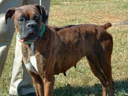
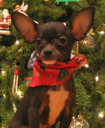
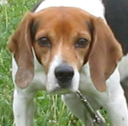
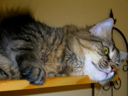

In [9]:
ds, info = tfds.load('cats_vs_dogs', split='train', with_info=True)

tfds.as_dataframe(ds.take(4), info)

### `tfds.show_examples`

`tfds.show_examples` devuelve un `matplotlib.figure.Figure` (por ahora solo se admiten datasets de im?genes):

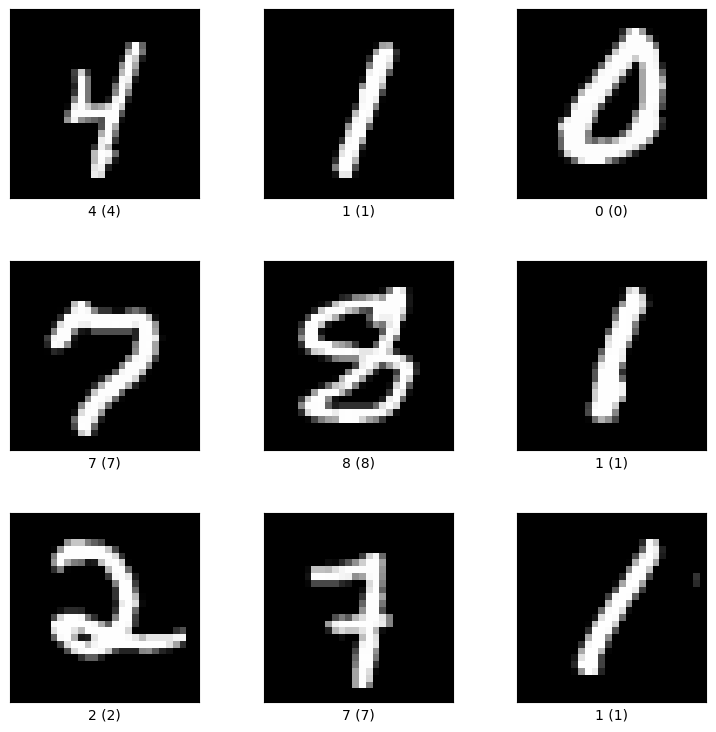

In [10]:
ds, info = tfds.load('mnist', split='train', with_info=True)

fig = tfds.show_examples(ds, info)

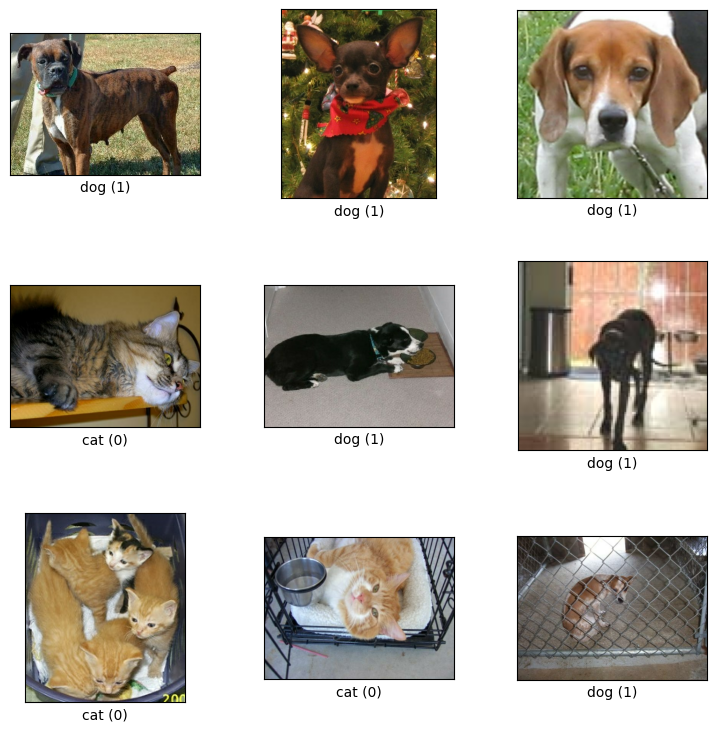

In [11]:
ds, info = tfds.load('cats_vs_dogs', split='train', with_info=True)

fig = tfds.show_examples(ds, info)

## Acceder a los metadatos del dataset

Todos los constructores incluyen un objeto `tfds.core.DatasetInfo` con los metadatos del dataset.

Se puede acceder a ?l mediante:

*   La API `tfds.load`: 


In [12]:
ds, info = tfds.load('mnist', with_info=True)

*   La API `tfds.core.DatasetBuilder`: 

In [13]:
builder = tfds.builder('mnist')
info = builder.info

La informaci?n del dataset contiene datos adicionales sobre el dataset (versi?n, cita, p?gina principal, descripci?n, ...).

In [14]:
print(info)

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='C:\\Users\\Cynthia\\tensorflow_datasets\\mnist\\3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume

Probamos con cats vs dogs:

In [15]:
ds, info = tfds.load('cats_vs_dogs', with_info=True)
builder = tfds.builder('cats_vs_dogs')
info = builder.info
print(info)

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='C:\\Users\\Cynthia\\tensorflow_datasets\\cats_vs_dogs\\4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy

### Metadatos de las caracter?sticas (nombres de etiquetas, forma de la imagen, ...)

Accede a `tfds.features.FeatureDict`:

In [16]:
info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'image/filename': Text(shape=(), dtype=string),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
})

N?mero de clases, nombres de etiquetas:

In [17]:
print(info.features["label"].num_classes)
print(info.features["label"].names)
print(info.features["label"].int2str(7))  # Versi?n legible para humanos (8 -> 'cat')
print(info.features["label"].str2int('7'))

2
['cat', 'dog']


IndexError: list index out of range

Formas, tipos de datos:

In [18]:
print(info.features.shape)
print(info.features.dtype)
print(info.features['image'].shape)
print(info.features['image'].dtype)

{'image': (None, None, 3), 'image/filename': (), 'label': ()}
{'image': tf.uint8, 'image/filename': tf.string, 'label': tf.int64}
(None, None, 3)
<dtype: 'uint8'>


### Metadatos de los splits (por ejemplo, nombres de splits, n?mero de ejemplos, ...)

Accede a `tfds.core.SplitDict`:

In [19]:
print(info.splits)

{'train': <SplitInfo num_examples=23262, num_shards=16>}


Splits disponibles:

In [20]:
print(list(info.splits.keys()))

['train']


Obtener informaci?n de un split individual:

In [21]:
print(info.splits['train'].num_examples)
print(info.splits['train'].filenames)
print(info.splits['train'].num_shards)

23262
['cats_vs_dogs-train.tfrecord-00000-of-00016', 'cats_vs_dogs-train.tfrecord-00001-of-00016', 'cats_vs_dogs-train.tfrecord-00002-of-00016', 'cats_vs_dogs-train.tfrecord-00003-of-00016', 'cats_vs_dogs-train.tfrecord-00004-of-00016', 'cats_vs_dogs-train.tfrecord-00005-of-00016', 'cats_vs_dogs-train.tfrecord-00006-of-00016', 'cats_vs_dogs-train.tfrecord-00007-of-00016', 'cats_vs_dogs-train.tfrecord-00008-of-00016', 'cats_vs_dogs-train.tfrecord-00009-of-00016', 'cats_vs_dogs-train.tfrecord-00010-of-00016', 'cats_vs_dogs-train.tfrecord-00011-of-00016', 'cats_vs_dogs-train.tfrecord-00012-of-00016', 'cats_vs_dogs-train.tfrecord-00013-of-00016', 'cats_vs_dogs-train.tfrecord-00014-of-00016', 'cats_vs_dogs-train.tfrecord-00015-of-00016']
16


Tambi?n funciona con la API de sub-splits:

In [22]:
print(info.splits['train[15%:75%]'].num_examples)
print(info.splits['train[15%:75%]'].file_instructions)

13957
[FileInstruction(filename='C:\\Users\\Cynthia\\tensorflow_datasets\\cats_vs_dogs\\4.0.1\\cats_vs_dogs-train.tfrecord-00002-of-00016', skip=581, take=873, examples_in_shard=1454), FileInstruction(filename='C:\\Users\\Cynthia\\tensorflow_datasets\\cats_vs_dogs\\4.0.1\\cats_vs_dogs-train.tfrecord-00003-of-00016', skip=0, take=1454, examples_in_shard=1454), FileInstruction(filename='C:\\Users\\Cynthia\\tensorflow_datasets\\cats_vs_dogs\\4.0.1\\cats_vs_dogs-train.tfrecord-00004-of-00016', skip=0, take=1453, examples_in_shard=1453), FileInstruction(filename='C:\\Users\\Cynthia\\tensorflow_datasets\\cats_vs_dogs\\4.0.1\\cats_vs_dogs-train.tfrecord-00005-of-00016', skip=0, take=1454, examples_in_shard=1454), FileInstruction(filename='C:\\Users\\Cynthia\\tensorflow_datasets\\cats_vs_dogs\\4.0.1\\cats_vs_dogs-train.tfrecord-00006-of-00016', skip=0, take=1454, examples_in_shard=1454), FileInstruction(filename='C:\\Users\\Cynthia\\tensorflow_datasets\\cats_vs_dogs\\4.0.1\\cats_vs_dogs-train.

## Soluci?n de problemas

### Descarga manual (si falla la descarga)

Si la descarga falla por alg?n motivo (por ejemplo, sin conexi?n, ...), siempre puedes descargar los datos manualmente y colocarlos en `manual_dir` (por defecto `~/tensorflow_datasets/downloads/manual/`).

Para saber qu? URLs descargar, revisa:

 * Para datasets nuevos (implementados como carpeta): [`tensorflow_datasets/`](https://github.com/tensorflow/datasets/tree/master/tensorflow_datasets/)`<type>/<dataset_name>/checksums.tsv`. Por ejemplo: [`tensorflow_datasets/datasets/bool_q/checksums.tsv`](https://github.com/tensorflow/datasets/blob/master/tensorflow_datasets/datasets/bool_q/checksums.tsv).

   Puedes encontrar la ubicaci?n de origen del dataset en [nuestro cat?logo](https://www.tensorflow.org/datasets/catalog/overview).
 * Para datasets antiguos: [`tensorflow_datasets/url_checksums/<dataset_name>.txt`](https://github.com/tensorflow/datasets/tree/master/tensorflow_datasets/url_checksums)

### Fixing `NonMatchingChecksumError`

TFDS garantiza la determinaci?n validando las sumas de verificaci?n de las URLs descargadas.
Si se lanza `NonMatchingChecksumError`, puede indicar lo siguiente:

  * El sitio web puede estar ca?do (por ejemplo, c?digo de estado `503`). Revisa la URL.
  * En el caso de URLs de Google Drive, intenta de nuevo m?s tarde, ya que Drive a veces rechaza descargas cuando demasiadas personas acceden a la misma URL. Ver [bug](https://github.com/tensorflow/datasets/issues/1482)
  * Es posible que los archivos originales del dataset se hayan actualizado. En ese caso, el constructor de TFDS deber?a actualizarse. Abre un nuevo issue o PR en GitHub:
     * Registra las nuevas sumas de verificaci?n con `tfds build --register_checksums`
     * Eventualmente, actualiza el c?digo de generaci?n del dataset.
     * Actualiza la `VERSION` del dataset
     * Actualiza las `RELEASE_NOTES` del dataset: ?qu? caus? el cambio en las sumas de verificaci?n? ?Cambi? alg?n ejemplo?
     * Aseg?rate de que el dataset todav?a pueda construirse.
     * Env?anos un PR

Nota: tambi?n puedes inspeccionar el archivo descargado en `~/tensorflow_datasets/download/`.


## Cita

Si est?s usando `tensorflow-datasets` para un art?culo, incluye la siguiente cita, adem?s de cualquier cita espec?fica de los datasets utilizados (que puede encontrarse en el [cat?logo de datasets](https://www.tensorflow.org/datasets/catalog/overview)).

```
@misc{TFDS,
  title = { {TensorFlow Datasets}, A collection of ready-to-use datasets},
  howpublished = {\url{https://www.tensorflow.org/datasets}},
}
```